In [ ]:
!fusermount -u /content/drive
!rm -rf /content/drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


In [ ]:
import os
import zipfile

# Define the path where you uploaded the zip file
ZIP_FILE_PATH = "/content/drive/MyDrive/Colab Notebooks/anterior_eye-20250406T084623Z-001.zip"

# Define the folder where you want to extract it
EXTRACT_PATH = "/content/drive/MyDrive/Colab Notebooks/anterior_eye"

# Extract the zip file
with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("✅ Dataset extracted successfully!")



✅ Dataset extracted successfully!


In [ ]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input

# Load Pre-trained VGG16 model (without the classification head)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Define dataset path
dataset_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/train"

# Function to extract features
def extract_features(directory):
    data = []
    labels = []

    for category in os.listdir(directory):  # Cataract, Normal
        category_path = os.path.join(directory, category)
        if os.path.isdir(category_path):
            for img_name in os.listdir(category_path):
                img_path = os.path.join(category_path, img_name)

                # Load image and preprocess
                img = load_img(img_path, target_size=(224, 224))
                img_array = img_to_array(img)
                img_array = np.expand_dims(img_array, axis=0)
                img_array = preprocess_input(img_array)  # Normalize for VGG16

                # Extract features
                features = base_model.predict(img_array)
                features = features.flatten()  # Flatten the feature map

                # Append to data
                data.append(features)
                labels.append(1 if category.lower() == "cataract" else 0)  # Convert to binary (Cataract=1, Normal=0)
  # Label (Cataract or Normal)

    return np.array(data), np.array(labels), features # Return features from the last iteration


# Extract features from dataset
X, y, features = extract_features(dataset_path) # Assign the returned features
print(f"Feature shape for an example image: {features.shape}") # Print shape without specific img_name


# Convert to DataFrame
df = pd.DataFrame(X)
df['label'] = y  # Add labels

# Save as CSV
csv_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/slit_vgg_train.csv"
df.to_csv(csv_path, index=False)

print(f"✅ CSV saved at: {csv_path}")
print(df.head())  # Print sample rows
print("Unique train labels:", np.unique(y))  # Check train labels

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━

In [ ]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input

# Load Pre-trained VGG16 model (without the classification head)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Define dataset path
dataset_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/test"

# Function to extract features
def extract_features(directory):
    data = []
    labels = []

    for category in os.listdir(directory):  # Cataract, Normal
        category_path = os.path.join(directory, category)
        if os.path.isdir(category_path):
            for img_name in os.listdir(category_path):
                img_path = os.path.join(category_path, img_name)

                # Load image and preprocess
                img = load_img(img_path, target_size=(224, 224))
                img_array = img_to_array(img)
                img_array = np.expand_dims(img_array, axis=0)
                img_array = preprocess_input(img_array)  # Normalize for VGG16

                # Extract features
                features = base_model.predict(img_array)
                features = features.flatten()  # Flatten the feature map

                # Append to data
                data.append(features)
                labels.append(1 if category.lower() == "cataract" else 0)  # Convert to binary (Cataract=1, Normal=0)
  # Label (Cataract or Normal)

    return np.array(data), np.array(labels), features # Return features from the last iteration


# Extract features from dataset
X, y, features = extract_features(dataset_path) # Assign the returned features
print(f"Feature shape for an example image: {features.shape}") # Print shape without specific img_name


# Convert to DataFrame
df = pd.DataFrame(X)
df['label'] = y  # Add labels

# Save as CSV
csv_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/slit_vgg_test.csv"
df.to_csv(csv_path, index=False)

print(f"✅ CSV saved at: {csv_path}")
print(df.head())  # Print sample rows
print("Unique train labels:", np.unique(y))  # Check train labels

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.8196 - loss: 0.5171 - val_accuracy: 0.9959 - val_loss: 0.1216
Epoch 2/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9902 - loss: 0.1460 - val_accuracy: 1.0000 - val_loss: 0.0946
Epoch 3/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9904 - loss: 0.1201 - val_accuracy: 0.9990 - val_loss: 0.0838
Epoch 4/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9951 - loss: 0.0920 - val_accuracy: 0.9980 - val_loss: 0.0716
Epoch 5/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9884 - loss: 0.1049 - val_accuracy: 1.0000 - val_loss: 0.0781
Epoch 6/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9924 - loss: 0.0932 - val_accuracy: 0.9980 - val_loss: 0.0733
Epoch 7/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9950 - loss: 0.0843 - val_accuracy: 1.0000 - val_loss: 0.0661
Epoch 8/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9955 - loss: 0.0745 - val_accuracy: 0

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9913 - loss: 0.0712
🎯 Test Accuracy: 99.59%


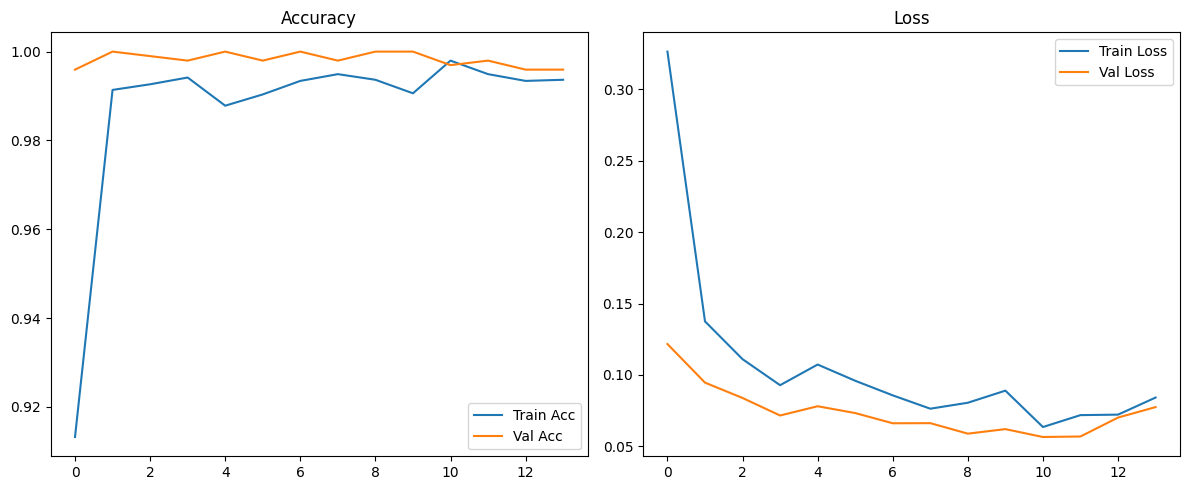

In [3]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ✅ Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# ✅ Load Data
train_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/slit_vgg_train.csv"
test_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/slit_vgg_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# ✅ Split Features and Labels
X_train, y_train = train_df.iloc[:, :-1].values, train_df.iloc[:, -1].values
X_test, y_test = test_df.iloc[:, :-1].values, test_df.iloc[:, -1].values

# ✅ Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ✅ Apply PCA (optional: reduce dimensions to 100 or tune based on variance)
pca = PCA(n_components=100)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# ✅ Define MLP Model with BatchNorm + Dropout
model = Sequential([
    Dense(64, activation='relu', kernel_regularizer=l2(0.001), input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

# ✅ Compile Model
model.compile(optimizer=Adam(learning_rate=0.005),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# ✅ Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# ✅ Train Model
history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=30,
                    batch_size=32,
                    callbacks=[early_stop],
                    verbose=1)

# ✅ Save Model
model.save('/content/drive/MyDrive/Colab Notebooks/anterior_eye/mlp_vgg5_model_revised.h5')

# ✅ Evaluate
loss, acc = model.evaluate(X_test, y_test)
print(f"🎯 Test Accuracy: {acc * 100:.2f}%")

# ✅ Plot Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.6872 - loss: 1.3707 - val_accuracy: 0.7992 - val_loss: 1.1030
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8896 - loss: 0.8887 - val_accuracy: 0.9077 - val_loss: 0.7821
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9393 - loss: 0.6669 - val_accuracy: 0.9483 - val_loss: 0.5898
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9535 - loss: 0.5504 - val_accuracy: 0.9604 - val_loss: 0.4997
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9714 - loss: 0.4674 - val_accuracy: 0.9828 - val_loss: 0.4218
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9746 - loss: 0.4276 - val_accuracy: 0.9858 - val_loss: 0.3845
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9786 - loss: 0.3863 - val_accuracy: 0.9868 - val_loss: 0.3501
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9829 - loss: 0.3598 - val_accuracy: 0.9868 - val_l

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9950 - loss: 0.2863


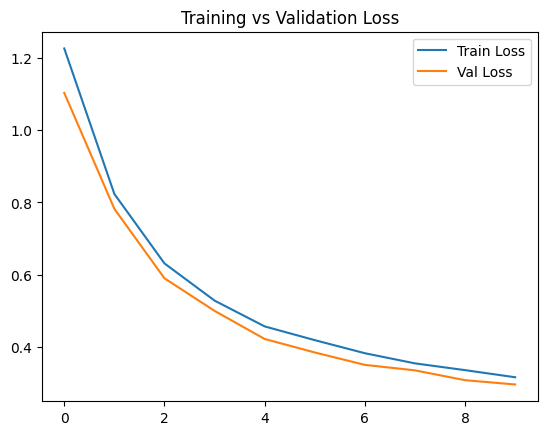

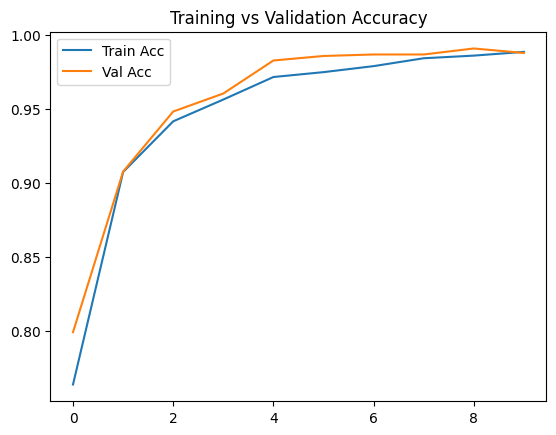

In [ ]:
!pip install tensorflow
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ✅ Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# ✅ Load Data
train_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/slit_vgg_train.csv"
test_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/slit_vgg_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# ⚠️ Only map labels if they are in text like 'cataract'/'normal'
# Here labels are already 0 and 1 → So skip mapping!

# ✅ Split Features and Labels
X_train, y_train = train_df.iloc[:, :-1].values, train_df.iloc[:, -1].values
X_test, y_test = test_df.iloc[:, :-1].values, test_df.iloc[:, -1].values

# ✅ Normalize features
max_value = np.max(X_train)  # Same scaling for both
X_train = X_train / max_value
X_test = X_test / max_value

# ✅ Define MLP Model
model = Sequential([
    Dense(64, activation='relu', kernel_regularizer=l2(0.005), input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=l2(0.005)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Output layer for Binary classification
])

# ✅ Compile Model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# ✅ Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# ✅ Train Model
history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=10,
                    batch_size=64,
                    callbacks=[early_stop],
                    verbose=1)
model.save('/content/drive/MyDrive/Colab Notebooks/anterior_eye/vgg22_slit_model.h5')


# ✅ Evaluate on Test Data
loss, acc = model.evaluate(X_test, y_test)

# ✅ Plot Loss Curve
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

# ✅ Plot Accuracy Curve
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()


39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

📈 ROC AUC Score: 0.9580


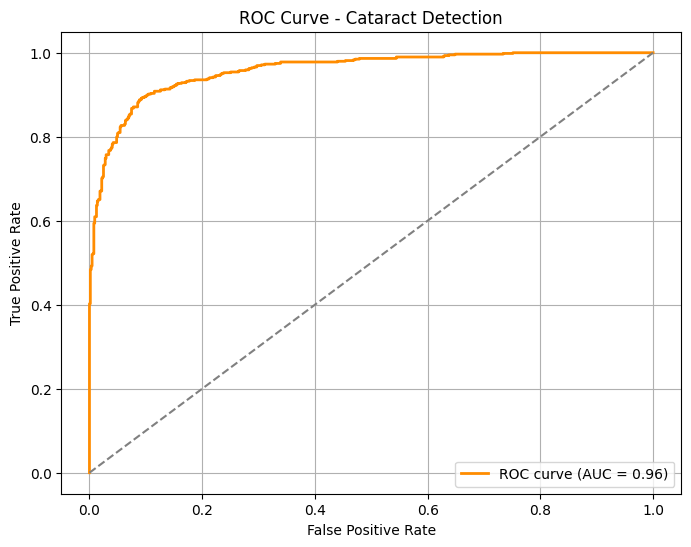

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
from tensorflow.keras.models import load_model
from sklearn.decomposition import PCA # Import PCA
from sklearn.preprocessing import StandardScaler # Import StandardScaler


# ---- Load test data ----
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/anterior_eye/slit_vgg_test.csv")
mlp_model = load_model("/content/drive/MyDrive/Colab Notebooks/anterior_eye/mlp_vgg5_model_revised.h5")

# ---- Convert string labels if needed ----
if df_test['label'].dtype == object:
    df_test['label'] = df_test['label'].map({'cataract': 1, 'normal': 0})

# ---- Separate features and labels ----
X_test = df_test.iloc[:, :-1].values
y_test = df_test.iloc[:, -1].values

# ---- Apply the same preprocessing as during training ----
scaler = StandardScaler() # Create a scaler object
X_test = scaler.fit_transform(X_test) # Scale the test data
pca = PCA(n_components=100) # Create a PCA object with 100 components
X_test = pca.fit_transform(X_test) # Apply PCA to the test data


# ---- Predict probabilities ----
y_pred_proba = mlp_model.predict(X_test)

# ---- Convert probabilities to binary predictions ----
y_pred = (y_pred_proba >= 0.5).astype(int).flatten()

# ---- ROC Curve and AUC ----
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n📈 ROC AUC Score: {auc:.4f}")

# ---- Plot ROC Curve ----
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Cataract Detection")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [9]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA # Import PCA
from sklearn.preprocessing import StandardScaler # Import StandardScaler

# ---- Load test features from CSV ----
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/anterior_eye/slit_vgg_test.csv")

# ---- Load trained MLP model correctly ----
mlp_model = load_model("/content/drive/MyDrive/Colab Notebooks/anterior_eye/mlp_vgg5_model_revised.h5")

# ✅ Check if labels need mapping before applying
# If labels are already 0 and 1, this step is skipped.
if df_test['label'].dtype == object:  # If labels are strings (like 'cataract', 'normal')
    df_test['label'] = df_test['label'].map({'cataract': 1, 'normal': 0})

# ---- Split features and labels ----
X_test = df_test.iloc[:, :-1].values  # Features
y_test = df_test.iloc[:, -1].values   # Labels

# ---- Apply the same preprocessing as during training ----
scaler = StandardScaler() # Create a scaler object
X_test = scaler.fit_transform(X_test) # Scale the test data
pca = PCA(n_components=100) # Create a PCA object with 100 components
X_test = pca.fit_transform(X_test) # Apply PCA to the test data

# ---- Predict test set ----
y_pred = mlp_model.predict(X_test)

# ---- Convert probability predictions to binary (0 or 1) ----
y_pred = (y_pred >= 0.5).astype(int)  # Threshold at 0.5
# ---- Flatten predictions ----
y_pred = y_pred.flatten().astype(int)

# ---- Evaluate performance ----
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Test Accuracy: {accuracy * 100:.2f}%")

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Normal", "Cataract"]))

print("\n🔹 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
🎯 Test Accuracy: 89.29%

📊 Classification Report:
              precision    recall  f1-score   support

      Normal       0.87      0.94      0.90       643
    Cataract       0.92      0.85      0.88       589

    accuracy                           0.89      1232
   macro avg       0.90      0.89      0.89      1232
weighted avg       0.90      0.89      0.89      1232


🔹 Confusion Matrix:
[[602  41]
 [ 91 498]]
